<a href="https://colab.research.google.com/github/JenniferShearer/ENDG-511-Project-Repo/blob/main/project_jenny_early_exit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import datasets

In [1]:
#upload kaggle.json
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"jennifershearer","key":"5529e94eaf186ebe27882dd6438bf917"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!pip install kagglehub

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ollioctopus/asl-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.27G/1.27G [00:17<00:00, 76.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/6


In [7]:
import subprocess
import sys
from pathlib import Path
import json
from dataclasses import dataclass
import math
from typing import Optional
from tqdm.auto import tqdm
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import h5py
from timm.utils import accuracy
from timm.layers import trunc_normal_
import matplotlib.pyplot as plt
import os
import random
from PIL import Image
from glob import glob
from sklearn.model_selection import train_test_split
import shutil
import pandas as pd
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model
import tensorflow as tf
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
!pip uninstall -y mediapipe
!pip install mediapipe==0.10.13

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 30.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.9 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 which is incompatible.


In [8]:
import shutil
import string
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import numpy as np
import random
from pathlib import Path
from tqdm import tqdm
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
import mediapipe as mp
import numpy as np
import random
import string
from sklearn.metrics import confusion_matrix, accuracy_score


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# Kaggle paths
# input_root = Path("ollioctopus/asl-dataset") # This line is redundant if the path is being set from a known location
input_root = Path(path) # Convert the string to a Path object
output_root = Path(path + "/combined_with_profile")
output_root.mkdir(parents=True, exist_ok=True)

# Valid class labels: a-z and 0-9
valid_classes = set(list(string.ascii_lowercase) + [str(i) for i in range(10)])
image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Find every folder anywhere in /kaggle/input that starts with "with_profile"
source_folders = [p for p in input_root.rglob("*") if p.is_dir() and p.name.startswith("with_profile")]

print(f"Found {len(source_folders)} source folders:\n")
for folder in source_folders:
    print(folder)

Found 10 source folders:

/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/6/with_profile_1
/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/6/with_profile
/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/6/with_profile_Jenny_1
/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/6/with_profile_Sam_push_1
/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/6/with_profile_Nathan_push_1
/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/6/with_profile_1/with_profile_1
/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/6/with_profile/with_profile
/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/6/with_profile_Jenny_1/with_profile_Jenny_1
/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/6/with_profile_Sam_push_1/with_profile_Sam_push_1
/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/6/with_profile_Nathan_push_1/with_profile_Nathan_push_1


In [11]:
if output_root.exists():
    print(f"Deleting existing folder: {output_root}")
    shutil.rmtree(output_root)

# Recreate the root folder
output_root.mkdir(parents=True, exist_ok=True)

print(f"{output_root} is now empty and ready for copying!")
copied_count = 0

for src_dir in source_folders:
    for class_dir in src_dir.iterdir():
        if class_dir.is_dir() and class_dir.name.lower() in valid_classes:
            class_name = class_dir.name.lower()
            target_class_dir = output_root / class_name
            target_class_dir.mkdir(exist_ok=True)

            for img_file in class_dir.iterdir():
                if img_file.is_file() and img_file.suffix.lower() in image_exts:
                    # Unique filename so nothing gets overwritten
                    base_name = f"{src_dir.parent.name}_{src_dir.name}_{img_file.stem}"
                    ext = img_file.suffix.lower()
                    target_file = target_class_dir / f"{base_name}{ext}"

                    counter = 1
                    while target_file.exists():
                        target_file = target_class_dir / f"{base_name}_{counter}{ext}"
                        counter += 1

                    shutil.copy2(img_file, target_file)
                    copied_count += 1

print(f"\nDone! Copied {copied_count} images into {output_root}")

Deleting existing folder: /root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/6/combined_with_profile
/root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/6/combined_with_profile is now empty and ready for copying!

Done! Copied 10584 images into /root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/6/combined_with_profile


In [19]:
dataset_roots = [
    path + "/data/data"#path + "/combined_with_profile"
]
#dataset_roots = [path + "/combined_with_profile"]

output_path = Path(path + "/dataset_split")
if output_path.exists():
    print(f"Deleting existing folder: {output_path}")
    shutil.rmtree(output_path)
output_path = path + '/dataset_split'


valid_ext = (".jpg", ".jpeg", ".png")

image_paths = []
labels = []

# Collect all images and labels from all roots
for dataset_root in dataset_roots:
    if not os.path.exists(dataset_root):
        continue

    for label in os.listdir(dataset_root):
        label_path = os.path.join(dataset_root, label)
        if not os.path.isdir(label_path):
            continue

        for f in os.listdir(label_path):
            if f.lower().endswith(valid_ext) and os.path.isfile(os.path.join(label_path, f)):
                image_paths.append(os.path.join(label_path, f))
                labels.append(label)

print(f"Found {len(image_paths)} images across {len(set(labels))} labels.")

# Train/Test split
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

# Function to copy files into train/test folders
def copy_to_split(paths, labels, split_name):
    for src_path, label in zip(paths, labels):
        dest_dir = os.path.join(output_path, split_name, label)
        os.makedirs(dest_dir, exist_ok=True)
        dest_path = os.path.join(dest_dir, os.path.basename(src_path))
        shutil.copy2(src_path, dest_path)

# Copy files into train/test structure
copy_to_split(train_paths, train_labels, "train")
copy_to_split(test_paths, test_labels, "test")

print("Dataset split complete!")

Deleting existing folder: /root/.cache/kagglehub/datasets/ollioctopus/asl-dataset/versions/6/dataset_split
Found 44075 images across 36 labels.
Dataset split complete!


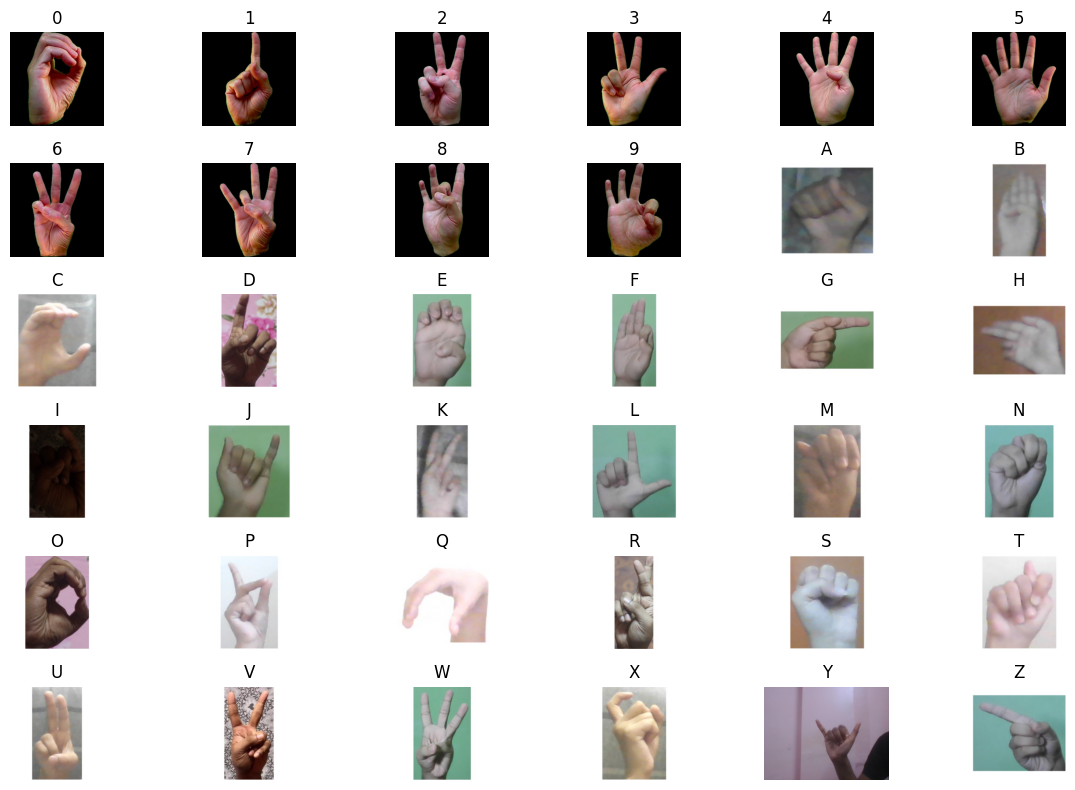

In [20]:
train_path = path + "/dataset_split/train"  # train path
labels = sorted(os.listdir(train_path))      # labels from folder names

plt.figure(figsize=(12, 8))

for i, label in enumerate(labels):
    label_path = os.path.join(train_path, label)

    if not os.path.isdir(label_path):
        continue

    # move images to class folder
    valid_ext = (".jpg", ".jpeg", ".png")
    images = [
        f for f in os.listdir(label_path)
        if f.lower().endswith(valid_ext) and os.path.isfile(os.path.join(label_path, f))
    ]

    if len(images) == 0:
        continue

    # pick one random image per class
    img_name = random.choice(images)
    img_path = os.path.join(label_path, img_name)
    img = Image.open(img_path)

    plt.subplot(6, 6, i + 1)
    plt.imshow(img)
    plt.title(label.upper())
    plt.axis("off")

plt.tight_layout()
plt.show()

load the base of MobileNetV2

In [21]:
BaseModel = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3))

Find what layers we should exit from:

In [22]:
for i, layer in enumerate(BaseModel.layers):
  print(i, layer.name)

0 input_layer_1
1 Conv1
2 bn_Conv1
3 Conv1_relu
4 expanded_conv_depthwise
5 expanded_conv_depthwise_BN
6 expanded_conv_depthwise_relu
7 expanded_conv_project
8 expanded_conv_project_BN
9 block_1_expand
10 block_1_expand_BN
11 block_1_expand_relu
12 block_1_pad
13 block_1_depthwise
14 block_1_depthwise_BN
15 block_1_depthwise_relu
16 block_1_project
17 block_1_project_BN
18 block_2_expand
19 block_2_expand_BN
20 block_2_expand_relu
21 block_2_depthwise
22 block_2_depthwise_BN
23 block_2_depthwise_relu
24 block_2_project
25 block_2_project_BN
26 block_2_add
27 block_3_expand
28 block_3_expand_BN
29 block_3_expand_relu
30 block_3_pad
31 block_3_depthwise
32 block_3_depthwise_BN
33 block_3_depthwise_relu
34 block_3_project
35 block_3_project_BN
36 block_4_expand
37 block_4_expand_BN
38 block_4_expand_relu
39 block_4_depthwise
40 block_4_depthwise_BN
41 block_4_depthwise_relu
42 block_4_project
43 block_4_project_BN
44 block_4_add
45 block_5_expand
46 block_5_expand_BN
47 block_5_expand_rel

The expabded relu is where we want to make the early exits, before it is projected

In [23]:
Exit1 = BaseModel.get_layer("block_3_expand_relu").output
Exit2 = BaseModel.get_layer("block_12_expand_relu").output

NewModel = Model(inputs=BaseModel.input,
                 outputs=[Exit1Output, Exit2Output, FinalOutput])


In [24]:
num_classes = len(labels)
print(f"{num_classes} classes for training.")

# redefine train_ds and test_ds using
# Set label_mode='categorical' for one-hot encoding as categorical_crossentropy is used
train_ds = tf.keras.utils.image_dataset_from_directory(
    output_path + "/train",
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical' # Ensures labels are one-hot encoded
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    output_path + "/test",
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical' # Ensures labels are one-hot encoded
)


train_ds = train_ds.map(lambda x, y: (x, (y, y, y))) #makes a training map that fits the early exit size
test_ds = test_ds.map(lambda x, y: (x, (y, y, y)))

for images, labels_one_hot in test_ds.take(1):
    break

36 classes for training.
Found 35260 files belonging to 36 classes.
Found 8815 files belonging to 36 classes.


In [ ]:
# Redefine the ExitHead function and the model with the correct number of classes
Exit1 = BaseModel.get_layer("block_2_expand_relu").output
Exit2 = BaseModel.get_layer("block_6_expand_relu").output

def ExitHead(x, num_classes_arg):
  x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
  x = layers.BatchNormalization()(x)
  x = layers.GlobalAveragePooling2D()(x)
  x = layers.Dense(128, activation='relu')(x)
  x = layers.Dropout(0.5)(x)
  return layers.Dense(num_classes_arg, activation='softmax')(x)

Exit1Output = ExitHead(Exit1, num_classes)
Exit2Output = ExitHead(Exit2, num_classes)

x = BaseModel.output
x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
FinalOutput = layers.Dense(num_classes, activation='softmax')(x)

NewModel = Model(inputs=BaseModel.input,
                 outputs=[Exit1Output, Exit2Output, FinalOutput])

# Compile the model with distinct metric instances for each output
NewModel.compile(
    optimizer='adam',
    loss=['categorical_crossentropy'] * 3,
    metrics=[
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top_3_acc_exit1'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top_3_acc_exit2'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top_3_acc_final')
    ]
)

# Fit the model
print("\nStarting model training...")
NewModel.fit(
    train_ds,
    validation_data = test_ds,
    epochs = 3,
)


Starting model training...
Epoch 1/3


In [ ]:
NewModel.save("/content/drive/MyDrive/Colab Notebooks/ENDG_511/Project/model_2_6.keras") #model_topk.keras")

In [ ]:
#run if you want to load model
LoadedModel = tf.keras.models.load_model("/content/drive/MyDrive/Colab Notebooks/ENDG_511/Project/model.keras")

In [40]:
#run if you want to use newely trained model
LoadedModel = NewModel

In [125]:
# Define paths to your four models (replace with your actual paths)
model_paths = [
    "/content/drive/MyDrive/Colab Notebooks/ENDG_511/Project/model_3_7.keras",
    "/content/drive/MyDrive/Colab Notebooks/ENDG_511/Project/model_4_10.keras",
    "/content/drive/MyDrive/Colab Notebooks/ENDG_511/Project/model_5_11.keras",
    "/content/drive/MyDrive/Colab Notebooks/ENDG_511/Project/model_7_12.keras"
]

list_of_models = []
for model_path in model_paths:
    try:
        model = tf.keras.models.load_model(model_path)
        list_of_models.append(model)
        print(f"Successfully loaded model from {model_path}")
    except Exception as e:
        print(f"Error loading model from {model_path}: {e}")

if not list_of_models:
    raise ValueError("No models were loaded. Please check the model paths.")

print(f"Loaded {len(list_of_models)} models for ensemble/multi-model evaluation.")


Successfully loaded model from /content/drive/MyDrive/Colab Notebooks/ENDG_511/Project/model_3_7.keras
Successfully loaded model from /content/drive/MyDrive/Colab Notebooks/ENDG_511/Project/model_4_10.keras
Successfully loaded model from /content/drive/MyDrive/Colab Notebooks/ENDG_511/Project/model_5_11.keras
Successfully loaded model from /content/drive/MyDrive/Colab Notebooks/ENDG_511/Project/model_7_12.keras
Loaded 4 models for ensemble/multi-model evaluation.


In [83]:
# Get the number of batches in the test_ds
num_batches = len(test_ds)

# Generate a random index to select a batch
random_index = 200#random.randint(0, num_batches - 1)

# Skip to the random index and take one batch
for images, labels_one_hot in test_ds.skip(random_index).take(1):
    break

print(f"Selected a random batch at index: {random_index}")

Selected a random batch at index: 200


In [43]:
# The 'results' array from LoadedModel.evaluate contains the metrics in a specific order:
# [total_loss, output_1_loss, output_2_loss, output_3_loss, output_1_top_k_acc, output_2_top_k_acc, output_3_top_k_acc]
# Since the model was compiled with `TopKCategoricalAccuracy(k=3)` for each of the 3 outputs,
# the last three values in the 'results' list correspond to these Top-3 accuracies.

top_k_acc_exit1 = results[4]
top_k_acc_exit2 = results[5]
top_k_acc_final = results[6]

print(f"Top-3 Accuracy for Exit 1 (Early Exit): {top_k_acc_exit1:.4f}")
print(f"Top-3 Accuracy for Exit 2 (Intermediate Exit): {top_k_acc_exit2:.4f}")
print(f"Top-3 Accuracy for Final Output: {top_k_acc_final:.4f}")

Top-3 Accuracy for Exit 1 (Early Exit): 0.4237
Top-3 Accuracy for Exit 2 (Intermediate Exit): 0.9111
Top-3 Accuracy for Final Output: 0.9847


In [42]:
results = LoadedModel.evaluate(test_ds, verbose=0)
metric_names = LoadedModel.metrics_names

# zip ensures matching length
df = pd.DataFrame(list(zip(metric_names, results)),
                  columns=["Metric", "Value"])

print(df.to_string(index=False))

         Metric    Value
           loss 8.611594
compile_metrics 6.382182
  dense_29_loss 1.899643
  dense_31_loss 0.329469
  dense_33_loss 0.423710


In [84]:
# Preprocess each image in the batch using the hand detection and cropping function
preprocessed_images = []
for img_tensor in images:
    preprocessed_img = preprocess_single_image_for_hand_detection(img_tensor)
    # Ensure the output is a tensor with the correct data type
    preprocessed_images.append(tf.convert_to_tensor(preprocessed_img, dtype=tf.float32))

# Stack the preprocessed images into a single tensor batch
preprocessed_images_batch = tf.stack(preprocessed_images)

# Make predictions using the preprocessed images batch
predictions = LoadedModel.predict(preprocessed_images_batch)
true_labels = tf.argmax(labels_one_hot[2], axis=1).numpy()
exit_names = ["Exit 1 (early exit)", "Exit 2 (intermediate exit)", "Final Output"]

for i, pred in enumerate(predictions):
    y_pred = np.argmax(pred, axis=1)
    accuracy = np.mean(y_pred == true_labels)
    print(f"Overall accuracy for {exit_names[i]}: {accuracy*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Overall accuracy for Exit 1 (early exit): 18.75%
Overall accuracy for Exit 2 (intermediate exit): 56.25%
Overall accuracy for Final Output: 68.75%


In [32]:
import tensorflow as tf

# Initialize MediaPipe Hands once for efficiency
mp_hands = mp.solutions.hands

def preprocess_single_image_for_hand_detection(image_input, target_size=224, padding=30):
    # Convert input to NumPy array if it's a TensorFlow tensor
    if tf.is_tensor(image_input):
        img_np_rgb = image_input.numpy().astype(np.uint8)
    else: # Assume it's already a NumPy array
        img_np_rgb = image_input.astype(np.uint8)

    # Convert RGB to BGR for OpenCV processing (internal to this function)
    img_bgr = cv2.cvtColor(img_np_rgb, cv2.COLOR_RGB2BGR)
    h, w, _ = img_bgr.shape

    with mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.5) as hands_detector:
        # MediaPipe expects RGB input
        results = hands_detector.process(img_np_rgb)

    processed_image = None

    if results.multi_hand_landmarks:
        # Hand detected, crop and resize
        hand_landmarks = results.multi_hand_landmarks[0]

        # Bounding box from landmarks
        x_coords = [lm.x * w for lm in hand_landmarks.landmark]
        y_coords = [lm.y * h for lm in hand_landmarks.landmark]

        x_min = max(int(min(x_coords)) - padding, 0)
        x_max = min(int(max(x_coords)) + padding, w)
        y_min = max(int(min(y_coords)) - padding, 0)
        y_max = min(int(max(y_coords)) + padding, h)

        # Crop image (using BGR image)
        cropped_bgr = img_bgr[y_min:y_max, x_min:x_max]

        # Resize the cropped image to target_size
        resized_bgr = cv2.resize(cropped_bgr, (target_size, target_size), interpolation=cv2.INTER_AREA)
        processed_image = resized_bgr

    else:
        # No hand detected, resize the entire original image
        resized_bgr = cv2.resize(img_bgr, (target_size, target_size), interpolation=cv2.INTER_AREA)
        processed_image = resized_bgr

    # Convert the processed BGR image back to RGB for model input
    return cv2.cvtColor(processed_image, cv2.COLOR_BGR2RGB)

Output:0


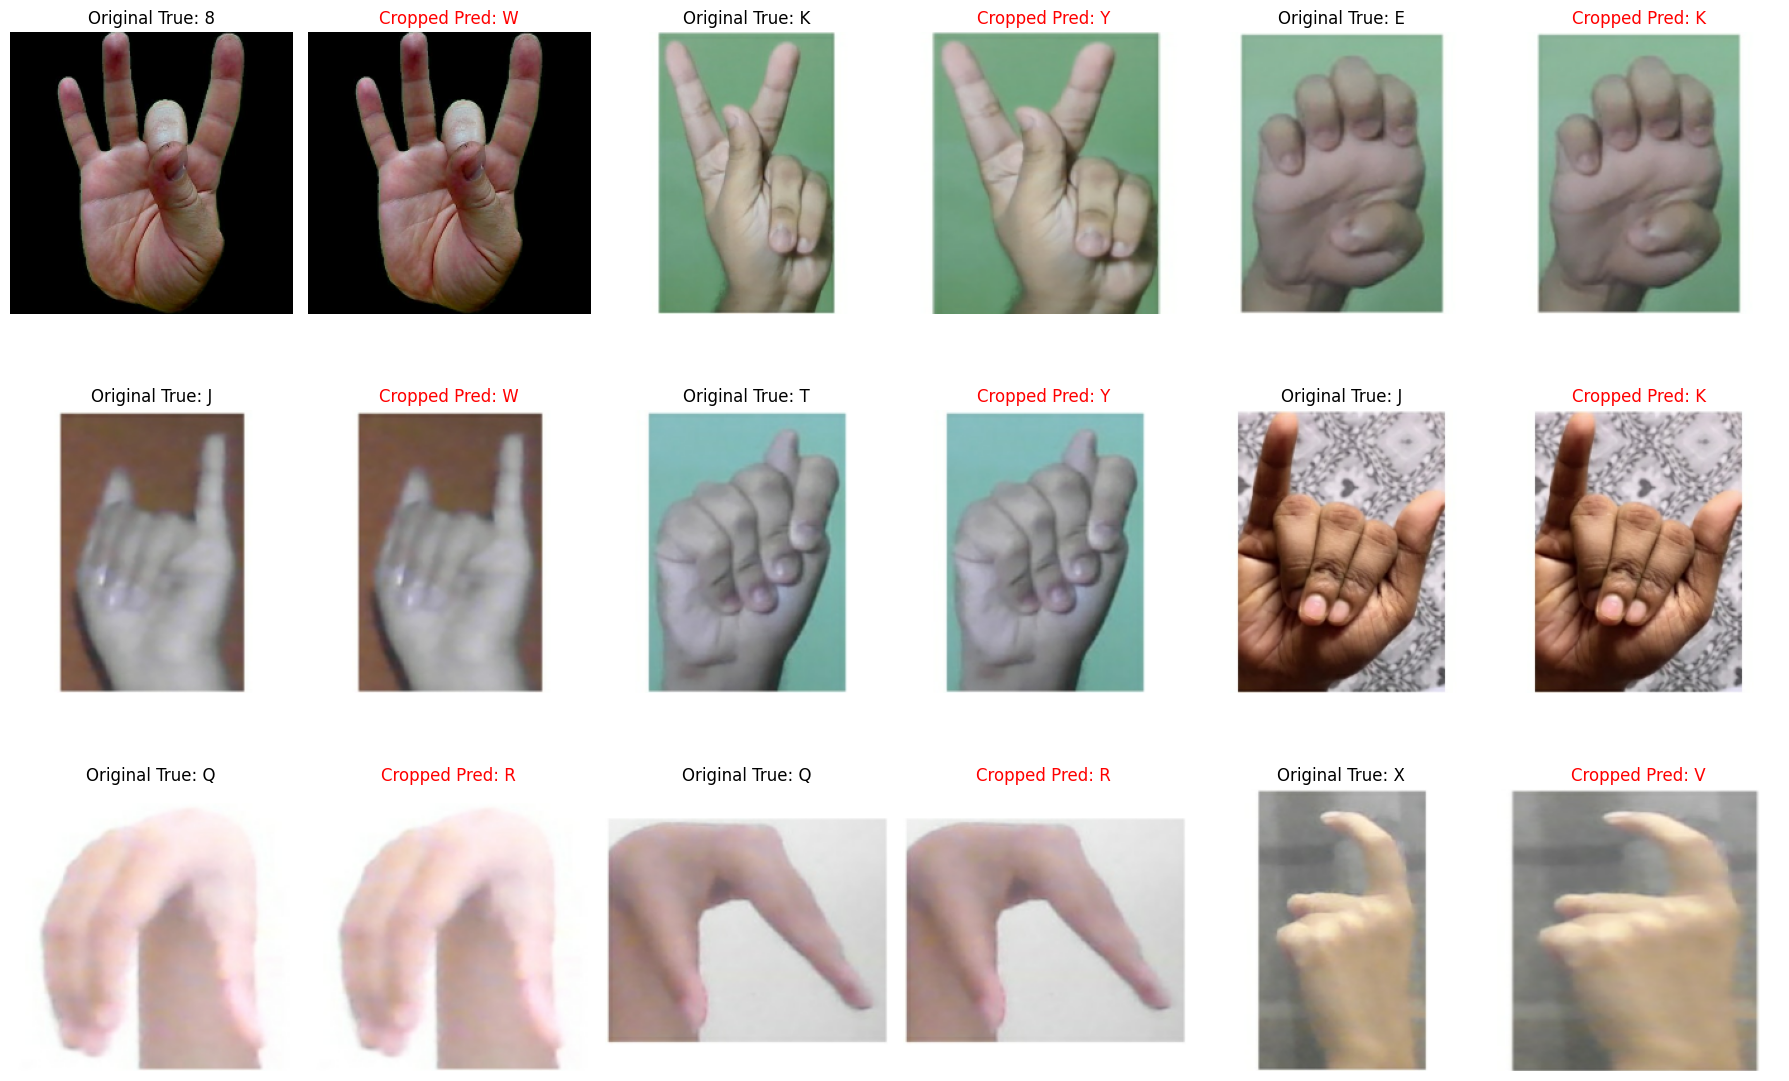

Output:1


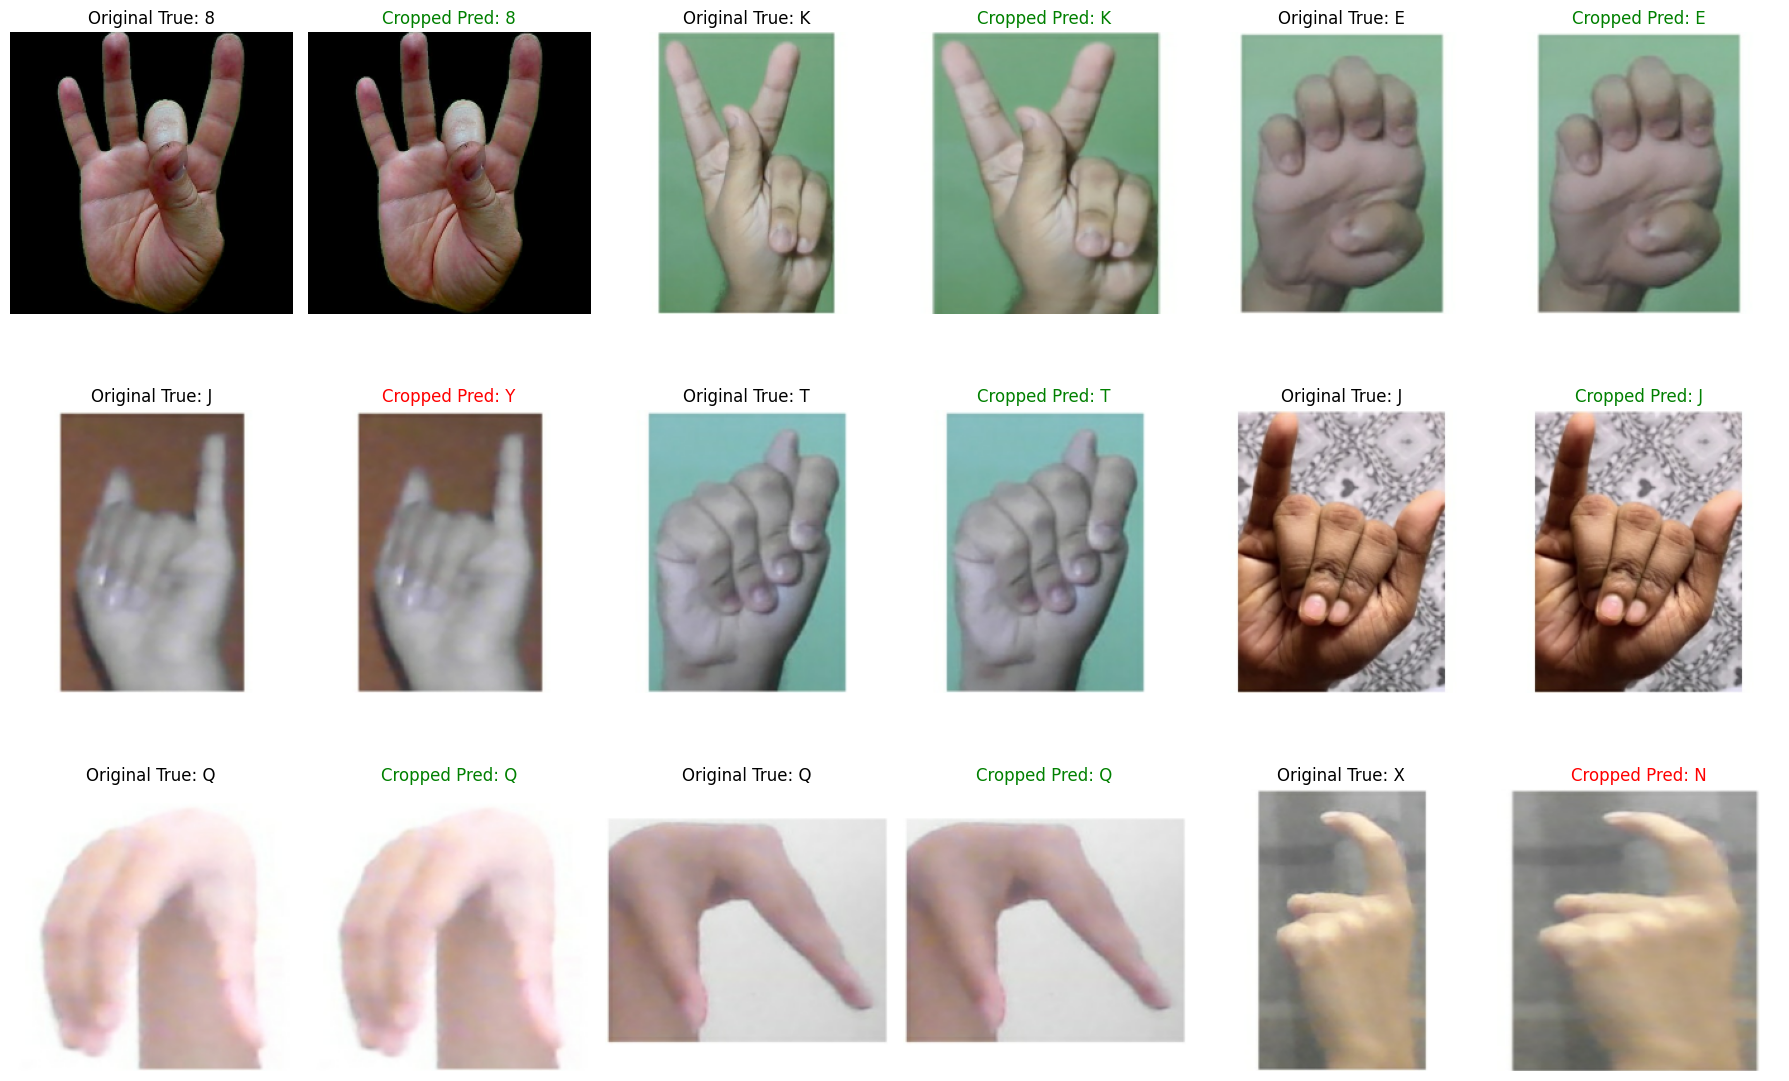

Output:2


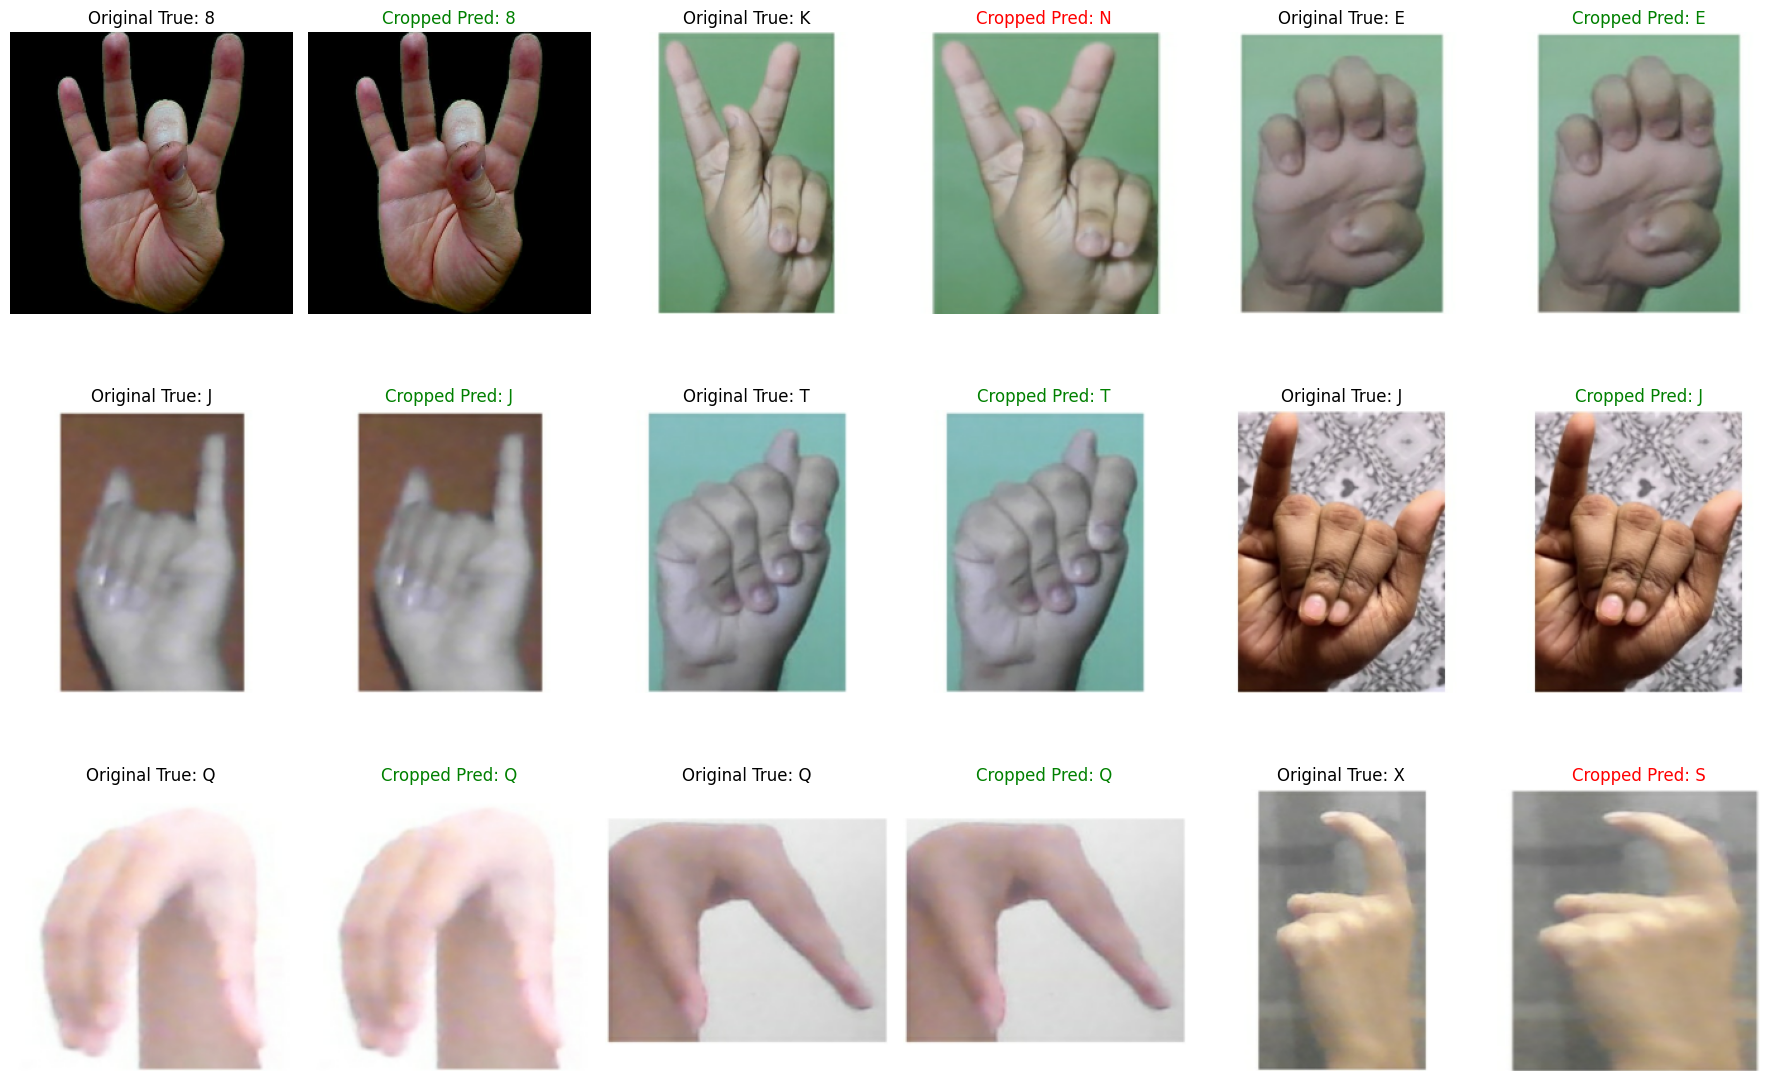

In [45]:
true_labels = tf.argmax(labels_one_hot[2], axis=1).numpy()
for j in range(3):
  print(f"Output:{j}")
  predicted_labels = tf.argmax(predictions[j], axis=1).numpy()

  plt.figure(figsize=(18, 12))
  for i in range(min(len(images), 9)): # Display up to 9 images
      # Original Image
      plt.subplot(3, 6, 2*i + 1) # First column for original
      plt.imshow(images[i].numpy().astype("uint8"))
      plt.title(f"Original True: {labels[true_labels[i]].upper()}")
      plt.axis("off")

      # Preprocessed Image and Prediction
      plt.subplot(3, 6, 2*i + 2) # Second column for preprocessed
      plt.imshow(preprocessed_images[i].numpy().astype("uint8"))

      true_class_name = labels[true_labels[i]]
      predicted_class_name = labels[predicted_labels[i]]

      color = "green" if true_class_name == predicted_class_name else "red"
      plt.title(f"Cropped Pred: {predicted_class_name.upper()}", color=color)
      plt.axis("off")

  plt.tight_layout()
  plt.show()

In [137]:
import numpy as np
import tensorflow as tf

# Initialize lists to store predictions for each exit from each model
# Structure: all_models_all_exit_preds[model_idx][exit_idx] = list of predictions for that exit
all_models_all_exit_preds = []
for _ in list_of_models: # One entry for each model
    all_models_all_exit_preds.append([[], [], []]) # Each model has 3 exits

y_true_list = []

# Loop over batches in test dataset
for batch_idx, (x_batch, y_batch) in enumerate(test_ds):

    # Preprocess the entire batch at once
    preprocessed_batch = tf.stack([preprocess_single_image_for_hand_detection(img)
                                   for img in x_batch])
    preprocessed_batch = tf.cast(preprocessed_batch, tf.float32)

    # Get predictions from each model
    for model_idx, model in enumerate(list_of_models):
        preds = model.predict(preprocessed_batch, verbose=0)
        # preds will be a list of 3 arrays, each array is (batch_size, num_classes)
        all_models_all_exit_preds[model_idx][0].extend(preds[0]) # Exit 1 predictions for current model
        all_models_all_exit_preds[model_idx][1].extend(preds[1]) # Exit 2 predictions for current model
        all_models_all_exit_preds[model_idx][2].extend(preds[2]) # Exit 3 predictions for current model

    # Get true labels from one-hot (take the first exit, all are identical)
    y_true_list.extend(tf.argmax(y_batch[0], axis=1).numpy())

    # Optional: limit to first N batches for quick testing
    if batch_idx == 20:
        break

# Convert lists to numpy arrays for easier processing
# Now, `all_models_all_exit_preds[model_idx][exit_idx]` will be a numpy array of shape (num_samples, num_classes)
for model_idx in range(len(list_of_models)):
    for exit_idx in range(3):
        all_models_all_exit_preds[model_idx][exit_idx] = np.array(all_models_all_exit_preds[model_idx][exit_idx])

y_true = np.array(y_true_list)

print(f"Collected raw predictions for {len(y_true)} samples from {len(list_of_models)} models.")

/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Collected raw predictions for 672 samples from 4 models.


In [127]:
def shannon_confidence(pred):
    pred = np.clip(pred, 1e-10, 1.0)  # avoid log(0)
    entropy = -np.sum(pred * np.log(pred))

    # normalize to [0, 1]
    max_entropy = np.log(len(pred))
    normalized_entropy = entropy / max_entropy

    # convert to confidence (higher = more confident)
    confidence = 1 - normalized_entropy

    return confidence

### Dynamic Early Exit Strategy Implementation

In [138]:

# Define a range of confidence thresholds to test
confidence_thresholds = np.arange(0.5, 1.0, 0.0001)

# Function to get results for a single set of model predictions
def evaluate_model_early_exit(model_preds_exit1, model_preds_exit2, model_preds_exit3, y_true, confidence_thresholds, model_name="", cost_exit1=1, cost_exit2=2, cost_final=3):
    results_list = []
    for confidence_threshold in confidence_thresholds:
        exit_taken = []
        final_predictions = []

        for i in range(len(y_true)):
            pred1 = model_preds_exit1[i]
            pred2 = model_preds_exit2[i]
            pred3 = model_preds_exit3[i]

            conf1 = shannon_confidence(pred1)
            conf2 = shannon_confidence(pred2)
            conf3 = shannon_confidence(pred3)

            if conf1 >= confidence_threshold:
                exit_taken.append(1)
                final_predictions.append(np.argmax(pred1))
            elif conf2 >= confidence_threshold:
                exit_taken.append(2)
                final_predictions.append(np.argmax(pred2))
            else:
                exit_taken.append(3)
                final_predictions.append(np.argmax(pred3))

        exit_taken = np.array(exit_taken)
        final_predictions = np.array(final_predictions)

        overall_accuracy = np.mean(final_predictions == y_true)
        average_cost = (np.sum(exit_taken == 1) * cost_exit1 + \
                        np.sum(exit_taken == 2) * cost_exit2 + \
                        np.sum(exit_taken == 3) * cost_final) / len(y_true)

        exit1_count = np.sum(exit_taken == 1)
        exit2_count = np.sum(exit_taken == 2)
        exit3_count = np.sum(exit_taken == 3)

        results_list.append({
            'Model Name': model_name,
            'Confidence Threshold': confidence_threshold,
            'Overall Accuracy': overall_accuracy,
            'Average Cost': average_cost,
            'Exit 1 %': exit1_count / len(y_true) * 100,
            'Exit 2 %': exit2_count / len(y_true) * 100,
            'Exit 3 %': exit3_count / len(y_true) * 100
        })

    return pd.DataFrame(results_list)

print("Dynamic Early Exit Strategy evaluation function defined.")

Dynamic Early Exit Strategy evaluation function defined.


In [139]:
import re

all_model_results = []

for model_idx, model in enumerate(list_of_models):
    # Extract predictions for the current model
    model_preds_exit1 = all_models_all_exit_preds[model_idx][0]
    model_preds_exit2 = all_models_all_exit_preds[model_idx][1]
    model_preds_exit3 = all_models_all_exit_preds[model_idx][2]

    model_full_path = model_paths[model_idx]
    model_name = Path(model_full_path).name
    print(f"Evaluating {model_name}...")

    # Extract costs from the model name (e.g., 'model_3_7.keras' -> exit1=3, exit2=7)
    match = re.search(r'model_(\d+)_(\d+)\.keras', model_name)
    if match:
        cost1 = int(match.group(1))+5
        cost2 = int(match.group(2))+5
        cost3 = 16 +5# Final weight is always 12 as requested
        print(f"  -> Using costs: Exit 1 = {cost1}, Exit 2 = {cost2}, Final Exit = {cost3}")
    else:
        # Default costs if naming convention doesn't match
        cost1 = 1
        cost2 = 2
        cost3 = 3
        print(f"  -> Could not parse costs from model name, using defaults: Exit 1 = {cost1}, Exit 2 = {cost2}, Final Exit = {cost3}")

    # Evaluate early exit strategy for the current model
    df_model_results = evaluate_model_early_exit(
        model_preds_exit1,
        model_preds_exit2,
        model_preds_exit3,
        y_true,
        confidence_thresholds,
        model_name,
        cost_exit1=cost1,
        cost_exit2=cost2,
        cost_final=cost3
    )
    all_model_results.append(df_model_results)

# Concatenate all individual model results into a single DataFrame
df_all_model_results = pd.concat(all_model_results, ignore_index=True)

print("\nCombined Dynamic Early Exit Strategy Results for All Models (with model-specific costs):")
display(df_all_model_results)

Evaluating model_3_7.keras...
  -> Using costs: Exit 1 = 8, Exit 2 = 12, Final Exit = 21
Evaluating model_4_10.keras...
  -> Using costs: Exit 1 = 9, Exit 2 = 15, Final Exit = 21
Evaluating model_5_11.keras...
  -> Using costs: Exit 1 = 10, Exit 2 = 16, Final Exit = 21
Evaluating model_7_12.keras...
  -> Using costs: Exit 1 = 12, Exit 2 = 17, Final Exit = 21

Combined Dynamic Early Exit Strategy Results for All Models (with model-specific costs):


,Model Name,Confidence Threshold,Overall Accuracy,Average Cost,Exit 1 %,Exit 2 %,Exit 3 %
0,model_3_7.keras,0.5000,0.339286,8.071429,98.214286,1.785714,0.000000
1,model_3_7.keras,0.5001,0.339286,8.071429,98.214286,1.785714,0.000000
2,model_3_7.keras,0.5002,0.339286,8.071429,98.214286,1.785714,0.000000
3,model_3_7.keras,0.5003,0.339286,8.071429,98.214286,1.785714,0.000000
4,model_3_7.keras,0.5004,0.339286,8.071429,98.214286,1.785714,0.000000
...,...,...,...,...,...,...,...
19995,model_7_12.keras,0.9995,0.875000,18.909226,9.077381,31.845238,59.077381
19996,model_7_12.keras,0.9996,0.876488,19.014881,8.035714,31.547619,60.416667
19997,model_7_12.keras,0.9997,0.879464,19.172619,7.142857,29.613095,63.244048
19998,model_7_12.keras,0.9998,0.879464,19.287202,6.398810,28.422619,65.178571


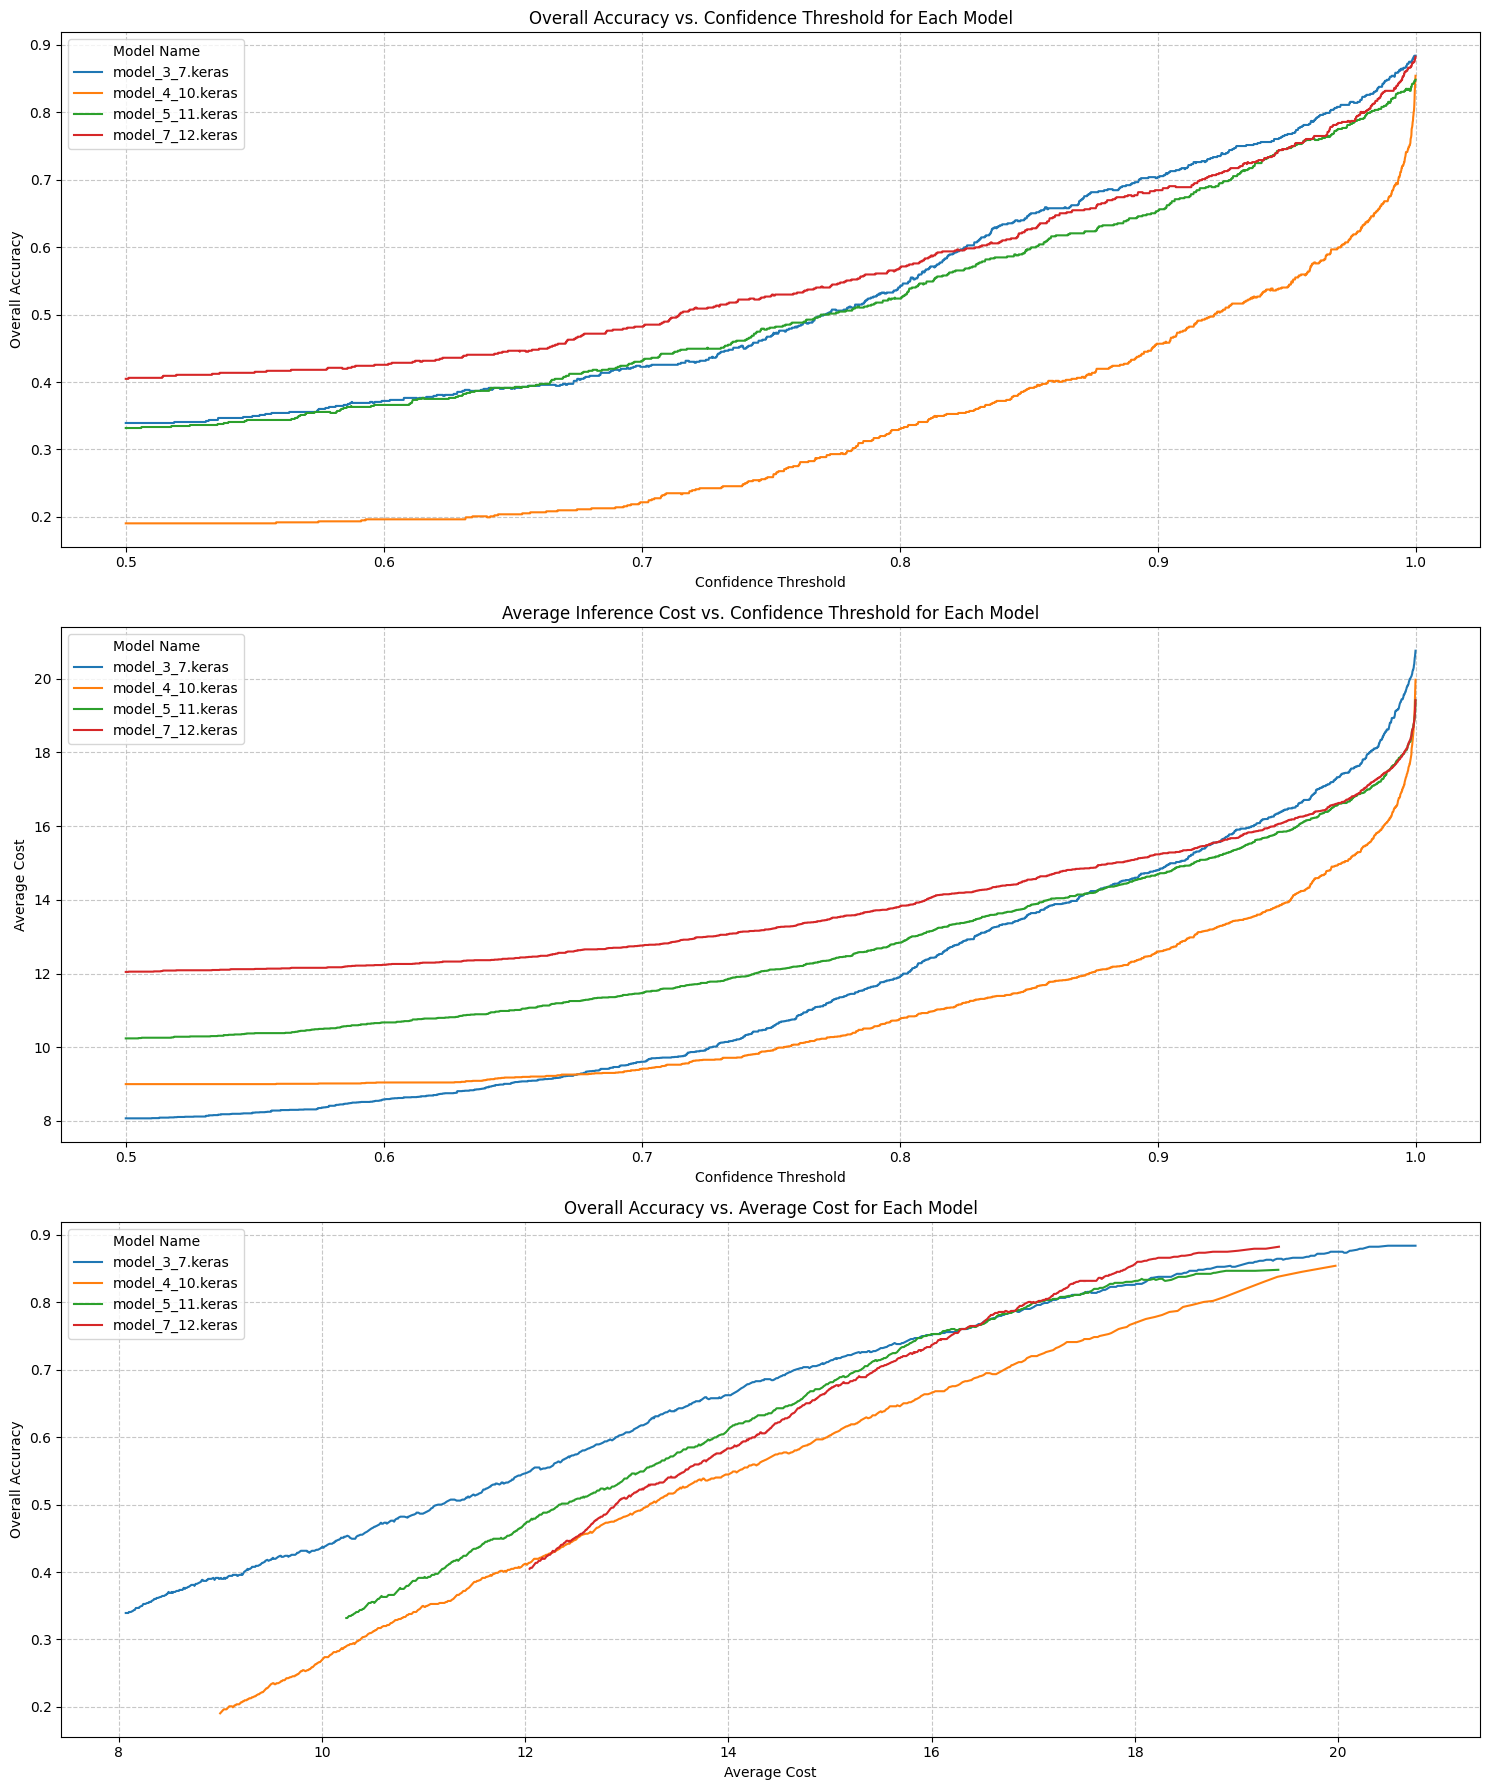

In [142]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots for better visualization
fig, axes = plt.subplots(3, 1, figsize=(15, 18))

# Plot 1: Overall Accuracy vs. Confidence Threshold for all models
sns.lineplot(ax=axes[0], x='Confidence Threshold', y='Overall Accuracy', hue='Model Name', data=df_all_model_results)
axes[0].set_title('Overall Accuracy vs. Confidence Threshold for Each Model')
axes[0].set_ylabel('Overall Accuracy')
axes[0].set_xlabel('Confidence Threshold')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Average Cost vs. Confidence Threshold for all models
sns.lineplot(ax=axes[1], x='Confidence Threshold', y='Average Cost', hue='Model Name', data=df_all_model_results)
axes[1].set_title('Average Inference Cost vs. Confidence Threshold for Each Model')
axes[1].set_ylabel('Average Cost')
axes[1].set_xlabel('Confidence Threshold')
axes[1].grid(True, linestyle='--', alpha=0.7)

# Plot 3: Overall Accuracy vs. Average Cost for all models
sns.lineplot(ax=axes[2], x='Average Cost', y='Overall Accuracy', hue='Model Name', data=df_all_model_results)
axes[2].set_title('Overall Accuracy vs. Average Cost for Each Model')
axes[2].set_xlabel('Average Cost')
axes[2].set_ylabel('Overall Accuracy')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

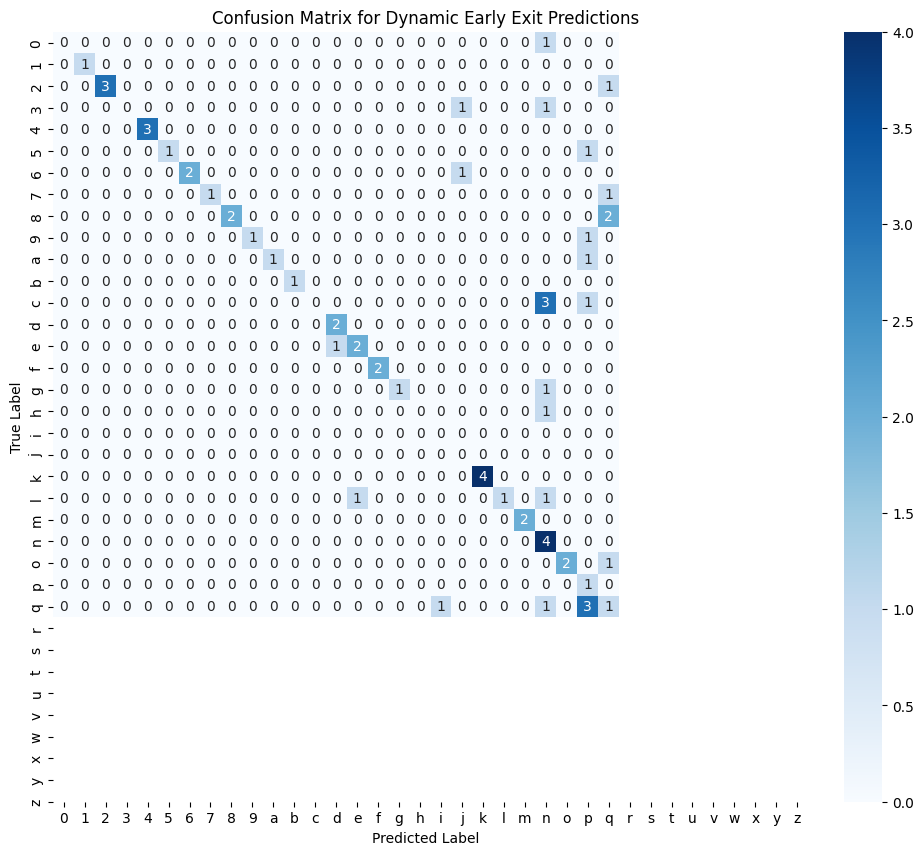

In [57]:
# Optional: Visualize the confusion matrix for the combined predictions
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get class labels if they are available (e.g., from your dataset loading)
# Assuming 'labels' variable holds the class names
if 'labels' in globals():
    class_names = labels
else:
    class_names = [str(i) for i in range(LoadedModel.outputs[0].shape[-1])]

cm_combined = confusion_matrix(y_true, final_predictions)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_combined, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Dynamic Early Exit Predictions')
plt.show()

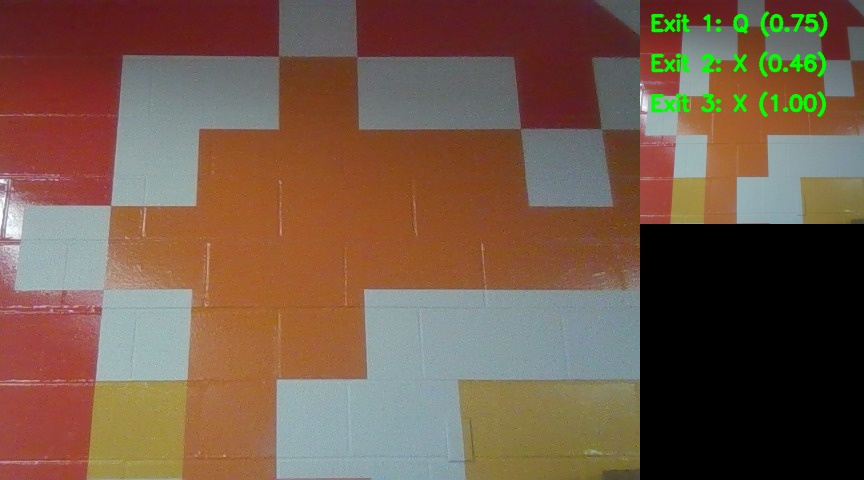

<IPython.core.display.Javascript object>

Click 'Start Capture Loop' to begin the fixed-frame predictions.


Starting capture loop for 60 frames...
Captured 60 frames. Stopping capture.
Starting capture loop for 60 frames...
Captured 60 frames. Stopping capture.
Starting capture loop for 60 frames...
Stopping capture loop.
Starting capture loop for 60 frames...
Captured 60 frames. Stopping capture.
Starting capture loop for 60 frames...
Captured 60 frames. Stopping capture.
Starting capture loop for 60 frames...
Captured 60 frames. Stopping capture.
Starting capture loop for 60 frames...
Captured 60 frames. Stopping capture.
Starting capture loop for 60 frames...
Captured 60 frames. Stopping capture.


In [ ]:
from IPython.display import display, Javascript, Image, HTML
from google.colab.output import eval_js, register_callback
from base64 import b64decode, b64encode
import cv2
import numpy as np
import PIL
import io
import html
import time
import tensorflow as tf

# Helper function to convert base64 string to bytes
def b64_to_bytes(b64_str):
    return b64decode(b64_str.split(',')[1])

# Initialize MediaPipe Hands once for efficiency
mp_hands = mp.solutions.hands

# Drawing functions (kept from previous implementation)
FONT = cv2.FONT_HERSHEY_SIMPLEX
FONT_SCALE = 1
FONT_THICKNESS = 2

def put_text_on_image(img, text, position, color=(255, 255, 255), scale=1, thickness=2):
    cv2.putText(img, text, position, FONT, scale, color, thickness, cv2.LINE_AA)

def draw_predictions(original_frame_bgr, preprocessed_frame_bgr, predictions, class_labels):
    display_width = original_frame_bgr.shape[1] + preprocessed_frame_bgr.shape[1]
    display_height = max(original_frame_bgr.shape[0], preprocessed_frame_bgr.shape[0])
    combined_frame = np.zeros((display_height, display_width, 3), dtype=np.uint8)

    combined_frame[0:original_frame_bgr.shape[0], 0:original_frame_bgr.shape[1]] = original_frame_bgr
    combined_frame[0:preprocessed_frame_bgr.shape[0], original_frame_bgr.shape[1]:] = preprocessed_frame_bgr

    x_offset = original_frame_bgr.shape[1]

    for i, pred_output in enumerate(predictions):
        predicted_class_index = np.argmax(pred_output)
        predicted_class_name = class_labels[predicted_class_index]
        confidence = pred_output[0, predicted_class_index]

        text = f"Exit {i+1}: {predicted_class_name.upper()} ({confidence:.2f})"
        color = (0, 255, 0)

        text_y_position = 30 + (i * 40)
        put_text_on_image(combined_frame, text, (x_offset + 10, text_y_position), color=(0, 255, 0), scale=0.7)

    return combined_frame

# Placeholder for the image display widget (now globally defined)
img_display = display(Image(data=b''), display_id=True)

# Get the list of labels from the dataset (now globally defined)
output_path = path + '/dataset_split'
class_labels = sorted(os.listdir(output_path + "/train"))

# JavaScript to set up webcam and send single frames to Python on demand
def init_streaming_javascript():
    js = Javascript('''
        var video;
        var canvas;
        var context;
        var streaming = false;

        async function setupCamera() {
            console.log('Setting up camera...');
            if (video && video.srcObject) {
                video.srcObject.getTracks().forEach(track => track.stop());
                video.remove();
            }
            if (canvas) {
                canvas.remove();
            }

            video = document.createElement('video');
            video.autoplay = true;
            video.playsinline = true;
            video.muted = true;
            video.width = 640;
            video.height = 480;

            video.style.display = 'none';
            video.style.display = 'block';
            video.style.transform = 'scaleX(-1)';

            const stream = await navigator.mediaDevices.getUserMedia({ video: true });
            video.srcObject = stream;
            document.body.appendChild(video);

            canvas = document.createElement('canvas');
            canvas.width = video.width;
            canvas.height = video.height;
            context = canvas.getContext('2d');
            //canvas.style.display = 'none';
            document.body.appendChild(canvas);

            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            return new Promise((resolve) => {
                video.onplaying = () => {
                    streaming = true;
                    console.log('Camera setup complete, video playing.');
                    resolve();
                };
            });
        }

    async function _captureAndSendFrameToPython_() {
        if (streaming && context) {
            context.save();
            context.scale(-1, 1);
            context.drawImage(video, -canvas.width, 0, canvas.width, canvas.height);
            context.restore();

            const dataURL = canvas.toDataURL('image/jpeg');
            google.colab.kernel.invokeFunction('handle_frame_from_js', [dataURL]);
        } else {
            console.log('Not streaming or context not available. Cannot capture frame.');
        }
    }

        // Exposed to Python: Initialize camera and start streaming mode
        window.initCamera = async function() {
            if (!streaming) {
                await setupCamera();
            }
        };

        // Exposed to Python: Request a single frame capture and send to Python
        window.requestSingleFrameFromJS = function() {
            if (streaming) {
                _captureAndSendFrameToPython_();
            } else {
                console.log('Camera not initialized or streaming stopped. Cannot request frame.');
            }
        };

        // Exposed to Python: Clean up camera resources and stop streaming mode
        window.cleanupCamera = function() {
            if (streaming) {
                streaming = false;
                if (video && video.srcObject) {
                    video.srcObject.getTracks().forEach(track => track.stop());
                    console.log('Video tracks stopped.');
                }
                if (video) {
                    video.remove();
                    console.log('Video element removed.');
                }
                if (canvas) {
                    canvas.remove();
                    console.log('Canvas element removed.');
                }
            }
            console.log('Streaming stopped and cleaned up.');
        };

        // Expose functions to Python
        google.colab.kernel.colabInternal.exposeOriginalApi(window.initCamera, window.requestSingleFrameFromJS, window.cleanupCamera);
    ''')
    display(js)

# Initialize the JavaScript for streaming setup
init_streaming_javascript()

print("Click 'Start Capture Loop' to begin the fixed-frame predictions.")

# Buttons to control the capture loop (will call Python callbacks)
button_html = '<button onclick="google.colab.kernel.invokeFunction(\'start_capture\', []);">Start Capture Loop</button>'
button_html += ' <button onclick="google.colab.kernel.invokeFunction(\'stop_capture\', []);">Stop Capture</button>'
display(HTML(button_html))

In [ ]:
# Python-side variables for controlling the capture loop
capture_limit = 60
current_frame_count = 0

# Define a Python function to start the capture process
def start_capture_python_side():
    global current_frame_count
    current_frame_count = 0
    print(f"Starting capture loop for {capture_limit} frames...")
    # Initialize camera in JavaScript
    eval_js('window.initCamera();')
    # Give camera a moment to warm up, then request the first frame
    time.sleep(1) # Small delay for camera to become ready
    eval_js('window.requestSingleFrameFromJS();')

# Define a Python function to stop the capture process
def stop_capture_python_side():
    global current_frame_count
    print("Stopping capture loop.")
    eval_js('window.cleanupCamera();')
    current_frame_count = 0 # Reset count on manual stop

# Define Python function to receive and process frames from JavaScript
def handle_frame_from_js(b64_image_data):
    global current_frame_count, capture_limit
    try:
        current_frame_count += 1
        #print(f"Processing frame {current_frame_count}/{capture_limit}")

        # Convert base64 to numpy array
        binary_img = b64_to_bytes(b64_image_data)
        img_np = cv2.imdecode(np.frombuffer(binary_img, np.uint8), cv2.IMREAD_COLOR)

        # Convert BGR to RGB for preprocessing and model input
        img_rgb = cv2.cvtColor(img_np, cv2.COLOR_BGR2RGB)

        # Preprocess the image
        preprocessed_img = preprocess_single_image_for_hand_detection(img_rgb)

        # Expand dims to create a batch of 1 for the model
        preprocessed_batch_for_model = tf.expand_dims(preprocessed_img, axis=0)

        # Get predictions from all exits
        predictions = LoadedModel.predict(preprocessed_batch_for_model, verbose=0)

        # Convert original RGB frame to BGR for drawing with OpenCV
        original_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
        # Convert preprocessed NumPy array back to BGR for drawing
        preprocessed_bgr = cv2.cvtColor(preprocessed_img.astype(np.uint8), cv2.COLOR_BGR2RGB)

        # Draw predictions on the combined frame
        output_frame = draw_predictions(original_bgr, preprocessed_bgr, predictions, class_labels)

        # Encode the output frame to JPEG and update the display
        _, encoded_img = cv2.imencode('.jpeg', output_frame)
        img_display.update(Image(data=encoded_img.tobytes()))

        # Request the next frame if limit not reached
        if current_frame_count < capture_limit:
            eval_js('window.requestSingleFrameFromJS();')
        else:
            print(f"Captured {capture_limit} frames. Stopping capture.")
            eval_js('window.cleanupCamera();')

    except Exception as e:
        print(f"Error processing frame: {e}")
        # Ensure camera is cleaned up on error
        eval_js('window.cleanupCamera();')

# Register the Python functions as callbacks
register_callback('start_capture', start_capture_python_side)
register_callback('stop_capture', stop_capture_python_side)
register_callback('handle_frame_from_js', handle_frame_from_js)

print("Python callbacks 'start_capture', 'stop_capture', and 'handle_frame_from_js' registered.")
print(f"Click 'Start Capture Loop' above to begin capturing {capture_limit} frames sequentially.")

Python callbacks 'start_capture', 'stop_capture', and 'handle_frame_from_js' registered.
Click 'Start Capture Loop' above to begin capturing 60 frames sequentially.


In [ ]:
# Run this cell to forcefully stop the webcam stream if needed.
# This calls the JavaScript stopStreaming function directly.
from IPython.display import Javascript
display(Javascript('window.stopStreaming();'))


<IPython.core.display.Javascript object>